In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from time import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import os
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

def test_train(df,test_size=0.2,seed=42):
    np.random.seed(seed)
    test_size = int(df.shape[0]*test_size)
    test_set = np.random.randint(0, df.shape[0],test_size)
    test_set = df.iloc[test_set,:].copy()
    train_set = df.loc[~df.index.isin(test_set.index),:].copy()
    return (train_set,test_set)

rdf = pd.read_csv(r'C:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\testing\SCL_data.csv',parse_dates=[0],index_col=0)
rdf['FCH4'] *= 1e3
print(rdf['FCH4'].count())
rdf['DOY'] = rdf.index.dayofyear
rdf['Month'] = rdf.index.month
mean_ch4,std_ch4 = rdf['FCH4'].mean(),rdf['FCH4'].std()
mean_co2,std_co2 = rdf['FCO2'].mean(),rdf['FCO2'].std()
rdf['FCH4_z'] = (rdf['FCH4'] - mean_ch4)/std_ch4
rdf['FCO2_z'] = (rdf['FCO2'] - mean_co2)/std_co2
figOut = 'C:\\Users\\jskeeter\\OneDrive - NRCan RNCan\\Documents\\Presentations\\CGU_2026\\images'

2795


<BarContainer object of 37 artists>

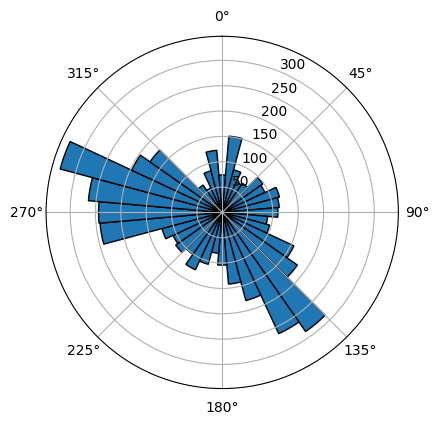

In [3]:
offset = -24.5
rdf['WD_1_1_1_c'] = rdf['WD_1_1_1'] + offset
rdf.loc[rdf['WD_1_1_1_c']<0,'WD_1_1_1_c']+= 360
rdf['WD_bin'] = ((rdf['WD_1_1_1'])/10).round()*10
wbins = rdf.groupby('WD_bin').count()['posix_time']


fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,2,1,projection='polar')
# ax2 = fig.add_subplot(1,2,2,projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.bar(wbins.index*np.pi/180,wbins,width=np.pi/180*10,edgecolor='k')
# ax2.set_theta_zero_location('N')
# ax2.set_theta_direction(-1)
# ax2.bar(wbins2.index*np.pi/180,wbins2,width=np.pi/180*10,edgecolor='k')


In [4]:
def RF_reg(df,X,y):
    print()
    ds = df[ X + [y]].dropna().copy()
    print(ds.shape)
    train,test = test_train(ds)
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", QuantileTransformer(n_quantiles=25), X),
            ])
    RF = make_pipeline(
        preprocessor,
        RandomForestRegressor(
            min_samples_leaf=10,
            random_state=42,
        ),
    )
    RF.fit(train[X],train[y])
    result = permutation_importance(RF, test[X], test[y], n_repeats=10, random_state=42)
    score = RF.score(test[X],test[y])
    print(f"Test R2 score: {score:.2f}")
    df[f"{y}_pred"] =np.nan
    df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] = RF.predict(df.loc[df[X].notnull().all(axis=1), X])
    return(df,pd.DataFrame(result.importances_mean,index=X).sort_values(0),score)
# rdf.columns


(18653, 7)
Test R2 score: 0.99

(13379, 7)
Test R2 score: 0.85

(18478, 7)
Test R2 score: 0.90

(5066, 7)
Test R2 score: 0.96

(5066, 7)
Test R2 score: 0.82

(5066, 7)
Test R2 score: 0.71


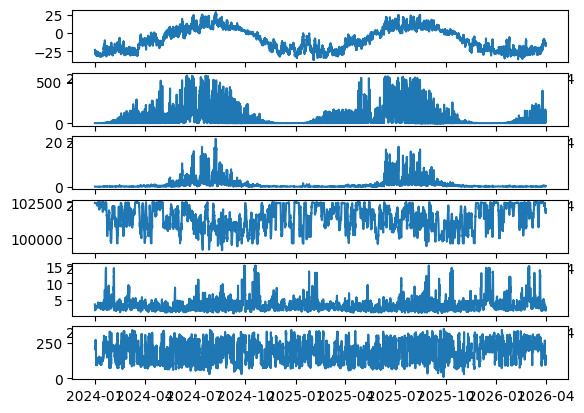

In [5]:
X = ['TA_NARR','SW_IN_NARR','RH_NARR','PA_NARR','uwind_NARR','vwind_NARR']
i = 0
fv = ['TA_1_1_1','SW_IN_1_1_1','VPD_1_1_1','PA_1_1_1','WS_1_1_1','WD_1_1_1']
fig,ax=plt.subplots(len(fv))
for y in fv:
    rdf,_,_=RF_reg(rdf,X,y)
    rdf[f"{y}_fill"] = rdf[y].fillna(rdf[f"{y}_pred"])
    ax[i].plot(rdf[f'{y}_pred'],label=f'Predicted Values {y}')
    i += 1
rdf = rdf.rename(columns={
    'SW_IN_1_1_1_fill':'SW_IN',
    'VPD_1_1_1_fill':'VPD',
    'TA_1_1_1_fill':'TA',
    'PA_1_1_1_fill':'PA',
    'WS_1_1_1_fill':'WS',
    'WD_1_1_1_fill':'WD'
})


(16453, 6)
Test R2 score: 1.00

(16817, 6)
Test R2 score: 1.00

(17415, 6)
Test R2 score: 1.00

(17415, 6)
Test R2 score: 1.00
Index(['FCH4', 'FCH4_QC', 'FCO2', 'FCO2_QC', 'H', 'H_QC', 'LE', 'LE_QC',
       'PA_1_1_1', 'PA_NARR', 'posix_time', 'P_NARR', 'RH_1_1_1', 'RH_NARR',
       'SW_IN_1_1_1', 'SW_IN_NARR', 'TA_1_1_1', 'TA_NARR', 'TS_1_1_1',
       'TS_1_2_1', 'TS_1_3_1', 'TS_1_4_1', 'ustar', 'uwind_NARR', 'VPD_1_1_1',
       'vwind_NARR', 'WD_1_1_1', 'WS_1_1_1', 'DOY', 'Month', 'FCH4_z',
       'FCO2_z', 'WD_1_1_1_c', 'WD_bin', 'TA_1_1_1_pred', 'TA',
       'SW_IN_1_1_1_pred', 'SW_IN', 'VPD_1_1_1_pred', 'VPD', 'PA_1_1_1_pred',
       'PA', 'WS_1_1_1_pred', 'WS', 'WD_1_1_1_pred', 'WD', 'TA_rolling_48',
       'SW_IN_rolling_48', 'TA_rolling_1440', 'SW_IN_rolling_1440',
       'TS_1_1_1_pred', 'TS_5cm', 'TS_1_2_1_pred', 'TS_25cm', 'TS_1_3_1_pred',
       'TS_50cm', 'TS_1_4_1_pred', 'TS_100cm'],
      dtype='object')


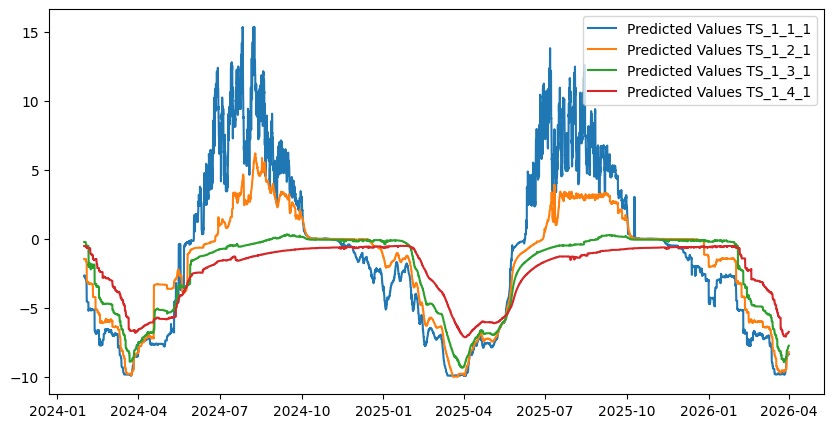

In [6]:
for n in [48,1440]:
    rdf[f'TA_rolling_{n}'] = rdf['TA'].rolling(window=n).mean()
    rdf[f'SW_IN_rolling_{n}'] = rdf['SW_IN'].rolling(window=n).sum()
# Fill TS
X = [
    'DOY',
    'TA',
    f'TA_rolling_48',
    f'TA_rolling_1440',
    f'SW_IN_rolling_1440',
    ]
plt.figure(figsize=(10,5))
for y in ['TS_1_1_1','TS_1_2_1','TS_1_3_1','TS_1_4_1']:
    rdf,_,_=RF_reg(rdf,X,y)
    rdf[f"{y}_fill"] = rdf[y].fillna(rdf[f"{y}_pred"])
    plt.plot(rdf[f'{y}_pred'],label=f'Predicted Values {y}')
plt.legend()
df = rdf.rename(columns={
    'TS_1_1_1_fill':'TS_5cm',
    'TS_1_2_1_fill':'TS_25cm',
    'TS_1_3_1_fill':'TS_50cm',
    'TS_1_4_1_fill':'TS_100cm',
})
print(df.columns)


(2795, 12)
Test R2 score: 0.79
                 0
Month     0.002623
VPD       0.010891
TA        0.019572
PA        0.024146
TS_5cm    0.033683
WS        0.060418
WD        0.081192
SW_IN     0.099653
TS_100cm  0.180150
TS_50cm   0.221624
TS_25cm   0.323273

(2656, 13)
Test R2 score: 0.76
                 0
Month     0.000496
TA        0.010165
VPD       0.010236
SW_IN     0.023331
PA        0.025784
TS_5cm    0.027721
WS        0.040750
WD        0.065322
FCO2      0.067506
TS_100cm  0.108106
TS_25cm   0.259806
TS_50cm   0.324662


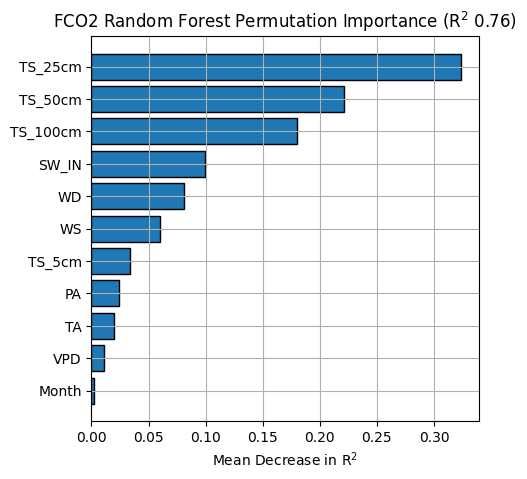

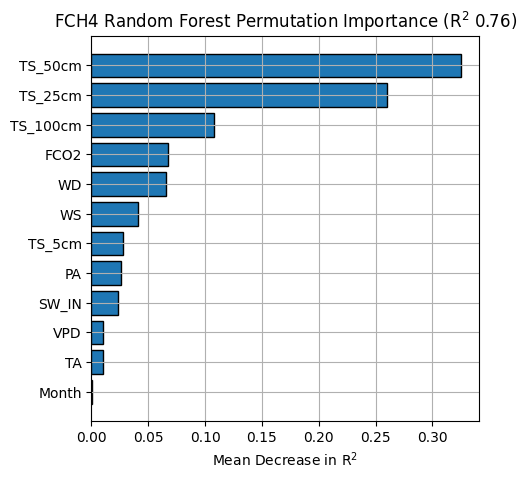

In [34]:
X_all = [
    'TA',
    'TS_5cm',
    'TS_25cm',
    'TS_50cm',
    'TS_100cm',
    'SW_IN',
    'VPD',
    'WS',
    'WD',
    'PA',
    'Month'
    ]

d_f,FI_CO2,score = RF_reg(df,X_all,'FCH4')
print(FI_CO2)
_,FI_CH4,score = RF_reg(df,X_all+['FCO2'],'FCH4')
print(FI_CH4)

fig,ax=plt.subplots(1,sharex=True,sharey=True,figsize=(5,5))
# ax[0].barh(FI_CO2.index,FI_CO2[0])
ax.barh(FI_CO2.index,FI_CO2[0],edgecolor='k')
ax.set_xlabel('Mean Decrease in R$^2$')
ax.set_title(f'FCO2 Random Forest Permutation Importance (R$^2$ {score:.2f})')
ax.grid('y')
plt.savefig(os.path.join(figOut,'FCO2_feature_importance.png'),dpi=300,bbox_inches='tight')

fig,ax=plt.subplots(1,sharex=True,sharey=True,figsize=(5,5))
# ax[0].barh(FI_CO2.index,FI_CO2[0])
ax.barh(FI_CH4.index,FI_CH4[0],edgecolor='k')
ax.set_xlabel('Mean Decrease in R$^2$')
ax.set_title(f'FCH4 Random Forest Permutation Importance (R$^2$ {score:.2f})')
ax.grid('y')
plt.savefig(os.path.join(figOut,'FCH4_feature_importance.png'),dpi=300,bbox_inches='tight')


In [18]:
def MPL_reg(df,X,y,n=5,nl=25,est=None):    
    Scores = []
    ds = df[ X + [y]].dropna().copy()
    # exit()
    df[f"{y}_pred"] = np.nan
    df.loc[df[X].notnull().all(axis=1), f"{y}_pred"] = 0
    if est is not None:
        est[f"{y}_pred"] = 0
    # print(X)
    # print(df.shape,df.loc[df[X].notnull().all(axis=1), X].shape)
    for seed in range(n):
        mlp_preprocessor = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), X),
            ]
        )
        train,test = test_train(ds,seed=seed,test_size=0.1)
        mlp_model = make_pipeline(
            mlp_preprocessor,
            MLPRegressor(
                hidden_layer_sizes=(nl),
                # learning_rate_init='adaptive',
                early_stopping=True,
                solver='lbfgs',
                activation='relu',
                verbose=True,
                n_iter_no_change=2,
                random_state=seed,
                max_iter=2000
            ),
        )
        
        mlp_model.fit(train[X],train[y])
        if y.startswith('FCH4'):
            df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] += mlp_model.predict(df.loc[df[X].notnull().all(axis=1), X])*std_ch4+mean_ch4
            if est is not None: 
                est[f'{y}_pred_{seed}'] = mlp_model.predict(est[X])*std_ch4+mean_ch4
        else:
            df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] += mlp_model.predict(df.loc[df[X].notnull().all(axis=1), X])*std_co2+mean_co2
            
            if est is not None: 
                est[f'{y}_pred_{seed}'] = mlp_model.predict(est[X])*std_co2+mean_co2
        # print(f"done in {time() - tic:.3f}s")
        score = mlp_model.score(test[X],test[y])
        Scores.append(score)
    df[f"{y}_pred"] /= n
    if est is not None:
        est[f"{y}_pred"] /= n
    print(f"Test R2 score: {np.median(np.array(Scores)):.2f}")
    return(df,n,est)

Test R2 score: 0.90


c:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Test R2 score: 0.66


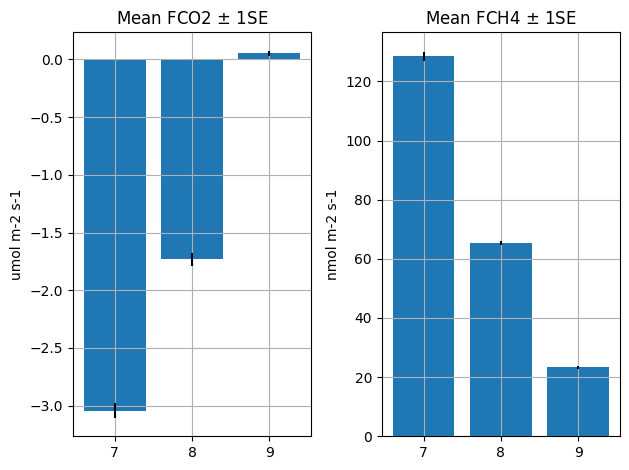

In [19]:
nm = 1
nl = 50
df_fill,nx,est = MPL_reg(df,X_all,'FCO2_z',n=nm,nl=nl)
df_fill['FCO2_f'] = df_fill['FCO2'].fillna(df_fill['FCO2_z_pred'])
df_fill,nx,est = MPL_reg(df_fill,X_all+['FCO2_f'],'FCH4_z',n=nm,nl=nl)
df_fill['FCH4_f'] = df_fill['FCH4'].fillna(df_fill['FCH4_z_pred'])
df_fill = df_fill.loc[(
    (df_fill.index.month>=7)
    &
    (df_fill.index.month<=9)
    &
    (df_fill.index.year>=2024)
    &
    (df_fill.index.year<=2025)
    )].copy()

fig,ax=plt.subplots(1,2)
agg = df_fill[['FCO2_f','FCH4_f']].groupby(df_fill.index.month).agg(['mean','std','count']).dropna()
ax[0].bar(agg.index,agg['FCO2_f']['mean'],yerr=agg['FCO2_f']['std']/agg['FCO2_f']['count']**.5,label='FCO2')
ax[0].set_ylabel('umol m-2 s-1')
ax[0].grid()
ax[0].set_title(r'Mean FCO2 $\pm$ 1SE')
ax[1].bar(agg.index,agg['FCH4_f']['mean'],yerr=agg['FCH4_f']['std']/agg['FCH4_f']['count']**.5,label='FCH4')
ax[1].set_ylabel('nmol m-2 s-1')
ax[1].grid()
ax[1].set_title(r'Mean FCH4 $\pm$ 1SE')
plt.tight_layout()
plt.savefig(os.path.join(figOut,'FCO2_FCH4_monthly.png'),dpi=300,bbox_inches='tight')


FCO2_f    -1.578603
FCH4_f    61.581932
dtype: float64
FCO2_f    0.094967
FCH4_f    2.092711
dtype: float64
2.3850791193600003 -5.96986848 -3.5847893606399994


C:\Users\jskeeter\AppData\Local\Temp\ipykernel_1868\2414367204.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  t.DOY = t.index.dayofyear+(t.index.hour+t.index.minute/60)/24
C:\Users\jskeeter\AppData\Local\Temp\ipykernel_1868\2414367204.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  t.DOY = t.index.dayofyear+(t.index.hour+t.index.minute/60)/24


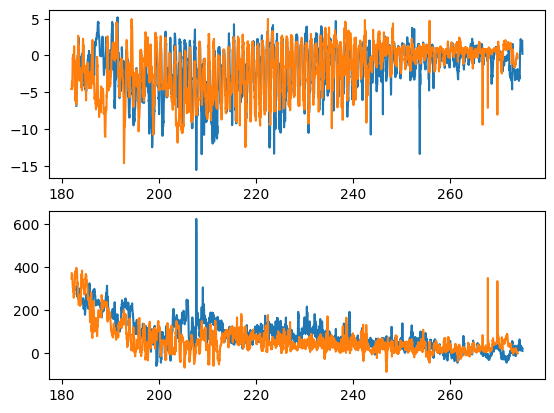

In [26]:

fig,ax=plt.subplots(2)
for y in [2024,2025]:
    t = df_fill.loc[df_fill.index.year == y,['FCO2_f','FCH4_f']]
    t.DOY = t.index.dayofyear+(t.index.hour+t.index.minute/60)/24
    ax[0].plot(t.DOY,t['FCO2_f'])
    ax[1].plot(t.DOY,t['FCH4_f'])
# print(t.describe())
print(t.mean())
print(t.std()/t.count()**.5*1.96)

A = 61.58*16.01*1e-9*1800*48*28
B = -1.57*44.01*1e-6*1800*48
print(A,B,A+B)
# df_fill.loc[((df_fill.index.month==8)&(df_fill.index.year==2024)),X_all+['FCH4','FCH4_z_pred','FCO2','FCO2_z_pred']].isna().sum()

dict_keys(['TS_25cm'])


c:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result

Test R2 score: 0.79


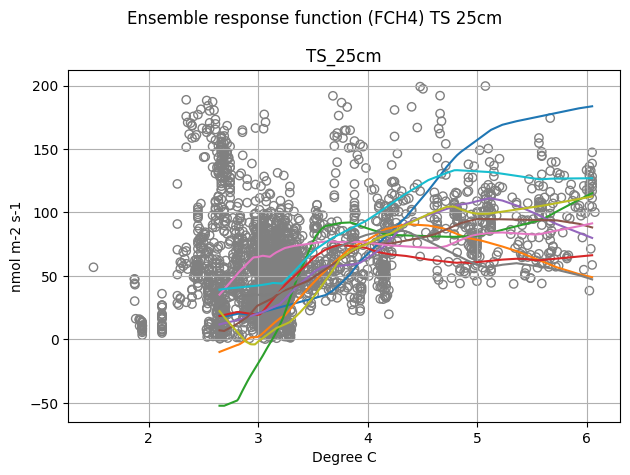

In [35]:

X = ['TS_5cm','TS_50cm']
# X = ['TS_5cm','Month','WD']
X = X_all
XO = ['Month','WD','PA','SW_IN','TA','WS','VPD','TS_100cm','TS_5cm','TS_50cm'] +['FCO2']

n = 100
ar = []
XP = []
for x in X:
    if 'Month' in X:
        ix = df['Month'] == 8
    else:
        ix = ~df['FCH4'].isna()
    if x not in XO:
        v = [df.loc[ix,x].quantile(i/n) for i in range(1,n)]
        ar.append(v)
        XP.append(x)
# if 'Month' in X:
data = {key: value.flatten() for key, value in zip(XP, np.meshgrid(*ar))}
print(data.keys())
for v in XO:
    if v in X:
        if v == 'Month':
           data['Month'] = np.ones(len(data[XP[0]]))*8
        elif v == 'WD':
            data['WD'] = np.ones(len(data[XP[0]]))*270
        else:
            data[v] = np.ones(len(data[XP[0]]))*df.loc[~df['FCH4'].isna(),v].mean()
        # print(data)
    
        
est = pd.DataFrame(data)
y = 'FCH4_z'
nm = 10

df_fill,nx,est=MPL_reg(df,X,y,est=est,n=nm,nl=nl)

L = len(XP)
fig,ax=plt.subplots(1,L,sharey=True)
try:
    if len(ax) > 1:
        pass
except:
    ax = [ax]

month = {7:'July',
         8:'August',
         9:'September'}
for j in range(L):
    # m = j + 8
    # m = 8
    x = XP[j]
    if x != 'Month' and x != 'WD':
        # if 'Month' in X:
        #     ix = np.array([est[xsub] == est[xsub].median() for xsub in XP if xsub != x and xsub != 'Month']).min(axis=0).astype(bool)
        # else:
        try:
            ix = np.array([est[xsub] == est[xsub].median() for xsub in XP if xsub != x and xsub not in XO]).min(axis=0).astype(bool)
            print(ix.sum())
            e = est.loc[ix]
        except:
            e = est.copy()
        
        T = df.sort_values(by=x).copy()
        ax[j].scatter(T[x],T['FCH4'],edgecolor='grey',facecolor='None')
        for i in range(nx):
            ax[j].plot(e[x],e[f'{y}_pred_{i}'])
        ax[j].set_title(f"{x}")
        ax[j].set_ylabel('nmol m-2 s-1')
        ax[j].set_xlabel('Degree C')
        ax[j].grid()
plt.suptitle(f"Ensemble response function (FCH4) TS 25cm")
plt.tight_layout()
plt.savefig(os.path.join(figOut,'TS_CH4_nn_response.png'))

In [ ]:
# X = ['TS_5cm','TS_50cm']
# X = ['TS_5cm','Month','WD']
X = X_all
XO = ['Month','WD','PA','SW_IN','TA','WS','VPD','TS_100cm','TS_5cm','TS_50cm']

n = 100
ar = []
XP = []
for x in X:
    if 'Month' in X:
        ix = df['Month'] == 8
    else:
        ix = ~df['FCH4'].isna()
    if x not in XO:
        v = [df.loc[ix,x].quantile(i/n) for i in range(1,n)]
        ar.append(v)
        XP.append(x)
# if 'Month' in X:
data = {key: value.flatten() for key, value in zip(XP, np.meshgrid(*ar))}
print(data.keys())
for v in XO:
    if v in X:
        if v == 'Month':
           data['Month'] = np.ones(len(data[XP[0]]))*8
        elif v == 'WD':
            data['WD'] = np.ones(len(data[XP[0]]))*270
        else:
            data[v] = np.ones(len(data[XP[0]]))*df.loc[~df['FCH4'].isna(),v].mean()
        # print(data)
    
        
est = pd.DataFrame(data)
y = 'FCO2_z'
# nm = 1

df_fill,nx,est=MPL_reg(df,X,y,est=est,n=nm,nl=nl)

L = len(XP)
fig,ax=plt.subplots(1,L,sharey=True)
try:
    if len(ax) > 1:
        pass
except:
    ax = [ax]

month = {7:'July',
         8:'August',
         9:'September'}
for j in range(L):
    # m = j + 8
    # m = 8
    x = XP[j]
    if x != 'Month' and x != 'WD':
        # if 'Month' in X:
        #     ix = np.array([est[xsub] == est[xsub].median() for xsub in XP if xsub != x and xsub != 'Month']).min(axis=0).astype(bool)
        # else:
        try:
            ix = np.array([est[xsub] == est[xsub].median() for xsub in XP if xsub != x and xsub not in XO]).min(axis=0).astype(bool)
            print(ix.sum())
            e = est.loc[ix]
        except:
            e = est.copy()
        
        T = df.sort_values(by=x).copy()
        ax[j].scatter(T[x],T['FCO2'],edgecolor='grey',facecolor='None')
        for i in range(nx):
            ax[j].plot(e[x],e[f'{y}_pred_{i}'])
        ax[j].set_title(f"{x}")
        ax[j].set_ylabel('umol m-2 s-1')
        ax[j].set_xlabel('Degree C')
        ax[j].grid()
plt.suptitle(f"Ensemble response function (FCO2) TS 25cm")
plt.tight_layout()
plt.savefig(os.path.join(figOut,'TS_CO2_nn_response.png'))

dict_keys(['TS_25cm'])


c:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result

TypeError: isinstance() arg 2 must be a type, a tuple of types, or a union

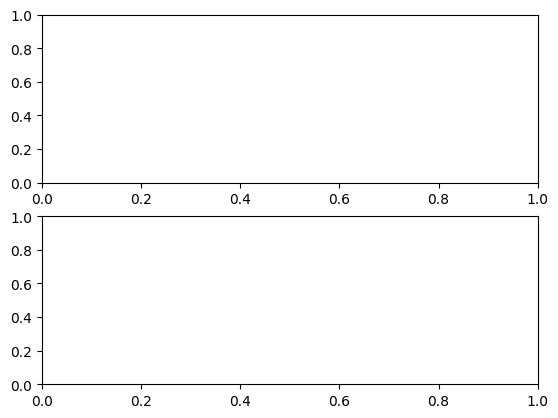

In [ ]:
# fig,ax = plt.subplots(2)
# isinstance(ax,np.array)

In [527]:
L

2

In [513]:
# np.array([est[xsub] == est[xsub].median() for xsub in X if xsub != x]).min(axis=0).astype(bool).sum()
# x,xsub
XP

['TS_5cm', 'TS_25cm', 'TS_50cm', 'TS_100cm', 'VPD']

In [ ]:
est

In [ ]:
n = 10
ar = []
for x in X[:-1]:
    print(x)
    ar.append([df.loc[df['Month'] == 8,x].quantile(i/n) for i in range(n+1)])
data = {key: value.flatten() for key, value in zip(X[:-1], np.meshgrid(*ar))}
data['Month'] = np.ones(len(data[X[0]]))*8
est = pd.DataFrame(data)
print(est['TS_5cm'].unique())
# est.quantile(.5)
# sum(sum([est[x] == est[x].median() for x in X[:-1]]))
# est.loc[sum([est[x] == est[x].median() for x in X])].describe()
# data['TS_5cm'].shape
# np.meshgrid()
# est.loc[est['TS_5cm'] == est['TS_5cm'].median()].describe()
# ar
# tuple(x for x in X)
est.loc[np.array([est[xsub] == est[xsub].median() for xsub in X[1:]]).min(axis=0).astype(bool)]
# print(est.shape)

In [ ]:

# df = pd.read_csv(r'C:\Users\jskeeter\gsc-permafrost\pyFluxPipeline\testing\rawData.csv',parse_dates=[0],index_col=0)
# plt.figure()
# plt.plot(df.index.dayofyear+df.index.hour/24+df.index.minute/60/24, df['Flux2024.ch4_flux'])
# plt.plot(df.index.dayofyear+df.index.hour/24+df.index.minute/60/24, df['Flux2025.ch4_flux'])

# fl = 'Flux2024'
# f2 = 'Flux2025'
# df['ch4_flux'] = df[[f'{fl}.ch4_flux',f'{f2}.ch4_flux']].mean(axis=1)
# df['ustar'] = df[[f'{fl}.ustar',f'{f2}.ustar']].mean(axis=1)
# df['ch4_signal_mean'] = df[[f'{fl}.diag_77_mean',f'{f2}.ch4_signal_mean']].mean(axis=1)
# df['wind_dir'] = df[[f'{fl}.wind_dir',f'{f2}.wind_dir']].mean(axis=1)
# df['wind_flag'] = 0
# df.loc[((df['wind_dir']<(180+33+30))&(df['wind_dir']>(180+33-30))),'wind_flag'] = 1
# print(df.loc[((df['ustar']>.1)&(df['ch4_signal_mean']>20)&(df['wind_flag']==0)&(df['ch4_signal_mean']>=20)),'ch4_flux'].count())
# df[[f'{fl}.ch4_flux',f'{f2}.ch4_flux','ch4_flux']].describe()


# est = pd.concat([
#     pd.DataFrame(data={
#         'TS_1_1_1_fill':np.linspace(ds['TS_1_1_1_fill'].min(),ds['TS_1_1_1_fill'].max(),n),
#         # 'SW_IN_1_1_1':np.ones(n)*ds.loc[ds['Month'] == m,'SW_IN_1_1_1'].quantile(.5),
#         'Month':np.ones(n)*m
#         }) for m in range(7,10)
#         ])

# mlp_preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), X),
#     ]
# )
# df[f'{y}_pred'] = np.nan
# n = 30
# print("Training MLPRegressor...")
# tic = time()
# nx = 5
# Scores = []
# for seed in range(0,nx):
#     train,test = test_train(ds,seed=seed,test_size=0.1)
#     mlp_model = make_pipeline(
#         mlp_preprocessor,
#         MLPRegressor(
#             hidden_layer_sizes=(50),
#             # learning_rate_init=0.001,
#             early_stopping=True,
#             solver='lbfgs',
#             activation='relu',
#             verbose=True,
#             n_iter_no_change=10,
#             random_state=seed,
#             max_iter=2000
#         ),
#     )
#     mlp_model.fit(train[X],train[y])
#     df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] += mlp_model.predict(df.loc[df[X].notnull().all(axis=1), X])*std+mean
#     est[f'{y}_pred_{seed}'] = mlp_model.predict(est[X])*std+mean
#     print(f"done in {time() - tic:.3f}s")
#     score = mlp_model.score(test[X],test[y])
#     Scores.append(score)
#     print(f"Test R2 score: {score:.2f}")
# df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] /= nx
# print(np.median(np.array(Scores)))


In [ ]:
# fig,ax=plt.subplots(2,2)
# fl = 'Flux2025'
# ax[0,0].scatter(df[f'{fl}.ch4_flux'],df[f'{fl}.qc_ch4_flux'])
# ax[0,1].scatter(df[f'{fl}.ch4_flux'],df[f'{fl}.diag_77_mean'])
# ax[1,0].scatter(df[f'{fl}.ch4_flux'],df[f'{fl}.ustar'])
# ax[1,1].scatter(df[f'{fl}.ch4_flux'],df[f'{fl}.wind_dir'])
# print(df.groupby(f'{fl}.qc_ch4_flux').count()[f'{fl}.ch4_flux'])

In [ ]:

print(df['FCH4'].count())
df['DOY'] = df.index.dayofyear
n = 48
df[f'TA_rolling_{n}'] = df['TA_1_1_1'].rolling(window=n).mean()
df[f'SW_IN_rolling_{n}'] = df['SW_IN_NARR'].rolling(window=n).mean()
X = [
    'DOY',
    # f'SW_IN_rolling_{n}',
    'TA_1_1_1',
    f'TA_rolling_{n}'
    ]


plt.figure(figsize=(10,5))
for y in ['TS_1_1_1','TS_1_2_1']:
    
    ds = df[ X + [y]].dropna().copy()
    train,test = test_train(ds)
    print(train.shape,test.shape)


    mlp_preprocessor = ColumnTransformer(
        transformers=[
            ("num", QuantileTransformer(n_quantiles=100), X),
            # ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    print("Training MLPRegressor...",y)
    tic = time()
    mlp_model = make_pipeline(
        mlp_preprocessor,
        MLPRegressor(
            hidden_layer_sizes=(30),
            random_state=42,
        ),
    )
    mlp_model.fit(train[X],train[y])
    df[f'{y}_pred'] = np.nan
    df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] = mlp_model.predict(df.loc[df[X].notnull().all(axis=1), X])
    df[f'{y}_fill'] = df[y].fillna(df[f'{y}_pred'])
    print(f"done in {time() - tic:.3f}s")
    print(f"Test R2 score: {mlp_model.score(test[X],test[y]):.2f}")

    x = 'DOY'
    plt.scatter(test[x].index,test[y],label=f'True Values {y}')
    plt.scatter(df.loc[test.index,x].index,df.loc[test.index,f'{y}_pred'],label=f'Predicted Values {y}')
plt.legend()

In [ ]:
plt.figure()
tf = df.loc[df.index.year==2024,:].copy()
plt.plot(tf.index.dayofyear+tf.index.hour/24,tf['FCH4'])
tf = df.loc[df.index.year==2025,:].copy()
plt.plot(tf.index.dayofyear+tf.index.hour/24,tf['FCH4'])

df['FCH4'].diff().describe()

# df['FCH4']

In [ ]:


X = ['SW_IN_1_1_1','TA_1_1_1','VPD_1_1_1','wind_speed','wind_dir','TS_1_1_1_fill']#,'TA_1_1_1','VPD_1_1_1','SW_IN_1_1_1']
X = ['TS_1_1_1_fill','Month']#,'Year']#,'TA_1_1_1','VPD_1_1_1','SW_IN_1_1_1']
df['Month'] = df.index.month
df['Year'] = df.index.year
y = 'FCH4'
ds = df.loc[df['FCH4_QC'] == 0, X + [y]].dropna().copy()

mean,std = ds['FCH4'].mean(),ds['FCH4'].std()
ds['FCH4'] = (ds['FCH4']-mean)/std

train,test = test_train(ds,seed=4,test_size=0.1)
print(train.shape,test.shape)

# x=X[-1]
train['FCH4'].describe()

In [ ]:
# import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer,StandardScaler


est = pd.concat([
    pd.DataFrame(data={
        'TS_1_1_1_fill':np.linspace(ds['TS_1_1_1_fill'].min(),ds['TS_1_1_1_fill'].max(),n),
        # 'SW_IN_1_1_1':np.ones(n)*ds.loc[ds['Month'] == m,'SW_IN_1_1_1'].quantile(.5),
        'Month':np.ones(n)*m
        }) for m in range(7,10)
        ])

mlp_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X),
    ]
)
df[f'{y}_pred'] = np.nan
n = 30
print("Training MLPRegressor...")
tic = time()
nx = 5
Scores = []
for seed in range(0,nx):
    train,test = test_train(ds,seed=seed,test_size=0.1)
    mlp_model = make_pipeline(
        mlp_preprocessor,
        MLPRegressor(
            hidden_layer_sizes=(50),
            # learning_rate_init=0.001,
            early_stopping=True,
            solver='lbfgs',
            activation='relu',
            verbose=True,
            n_iter_no_change=10,
            random_state=seed,
            max_iter=2000
        ),
    )
    mlp_model.fit(train[X],train[y])
    df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] += mlp_model.predict(df.loc[df[X].notnull().all(axis=1), X])*std+mean
    est[f'{y}_pred_{seed}'] = mlp_model.predict(est[X])*std+mean
    print(f"done in {time() - tic:.3f}s")
    score = mlp_model.score(test[X],test[y])
    Scores.append(score)
    print(f"Test R2 score: {score:.2f}")
df.loc[df[X].notnull().all(axis=1), f'{y}_pred'] /= nx
print(np.median(np.array(Scores)))


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))


x = X[0]
# plt.scatter(test[x],test['FCH4'],label='True Values')
c = ['red','blue','black']
fig,ax=plt.subplots(1,sharex=True,sharey=True)
ax=[ax]
for j in range(1):
    m = j + 8
    e = est.loc[est['Month'] == m].sort_values(by=x)
    T = df.loc[df['Month'] == m].sort_values(by=x)
    ax[j].scatter(T[x],T['FCH4'],edgecolor='k',facecolor='None')
    for i in range(nx):
        ax[j].plot(e[x],e[f'{y}_pred_{i}'],color='red')

In [ ]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict


indir = r'E:\temp\TOA5_extraction\notdups'
outdir = r'E:\data-dump\SCL\corrected'
allFiles = [os.path.join(indir, f) for f in os.listdir(indir) if 'Time_Series' in f]
print(len(allFiles))

for tf in allFiles:
    H = []
    with open(tf, 'r') as f:
        for i in range(4):
            H.append(f.readline())
        df = pd.read_csv(f,header=None,na_values='"NAN"',names=H[1].replace('"', '').replace('\n','').split(','))
    for c in df.columns:
        if c.startswith('LI77'):
            df[c] = df[c].astype('float')
    df.head()

    # Correct CH4
    # LI7700_amb_tmpr="LI7700_temperature"
    # LI7700_amb_press="LI7700_pressure"
    # FCH4_mass="LI7700_CH4D"
    # def kTP(TP,t2,t1,p2,p1,c):
    #     T,P = TP
    #     return (t2*T**2+t1*T+p2*P**2+p1*P+c)
    # df[LI7700_amb_tmpr]+273.15
    # TP = np.vstack(((df[LI7700_amb_tmpr].values+273.15),df[LI7700_amb_press].values))
    # k = kTP(TP,*[6.37856586e-06,-2.69695519e-03,8.32661719e-05,-7.24864231e-03,1.11848651e+00])
    # # print(df[FCH4_mass].describe())
    # df[FCH4_mass] = df[FCH4_mass]*df[LI7700_amb_press]/((df[LI7700_amb_tmpr]+273.15)*8.314*k)
    # # print(df[FCH4_mass].describe())

    fn = 'Time_Series'+pd.to_datetime(df['TIMESTAMP'].iloc[0]).strftime('%Y%m%d%H%M')+'.dat'
    fn = os.path.join(outdir, fn)
    # with open(fn,'w+') as f:
    #     for h in H:
    #         f.write(h)
    df.to_csv(fn,header=False,index=False)

    print(fn)

In [ ]:
H

In [ ]:
df[df.columns[2:6]]

In [ ]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict


indir = r'E:\temp\TOA5_extraction'
outdir = r'E:\data-dump\SCL\corrected'
tf = [os.path.join(indir, f) for f in os.listdir(indir) if 'Time_Series' in f][1]
print(tf)

H = []
defaultTypes = defaultdict(lambda: '<f4',RECORD ='<u4',TIMESTAMP = 'str')

with open(tf, 'r') as f:
    for i in range(5):
        H.append(f.readline())
        H[i] = H[i].replace('"', '').replace('\n','').split(',')
    print(f)
    df = pd.read_csv(f,header=None,na_values='"NAN"',names=H[1])
for c in df.columns:
    if c.startswith('LI77'):
        df[c] = df[c].astype('float')
df.head()

# Correct CH4
LI7700_amb_tmpr="LI7700_temperature"
LI7700_amb_press="LI7700_pressure"
FCH4_mass="LI7700_CH4D"
def kTP(TP,t2,t1,p2,p1,c):
    T,P = TP
    return (t2*T**2+t1*T+p2*P**2+p1*P+c)
df[LI7700_amb_tmpr]+273.15
TP = np.vstack(((df[LI7700_amb_tmpr].values+273.15),df[LI7700_amb_press].values))
k = kTP(TP,*[6.37856586e-06,-2.69695519e-03,8.32661719e-05,-7.24864231e-03,1.11848651e+00])
print(df[FCH4_mass].describe())
df[FCH4_mass] = df[FCH4_mass]*df[LI7700_amb_press]/((df[LI7700_amb_tmpr]+273.15)*8.314*k)
print(df[FCH4_mass].describe())

fn = 'Time_Series_smol_'+pd.to_datetime(df['TIMESTAMP'].iloc[0]).strftime('%Y%m%d%H%M')+'.dat'
with open(os.path.join(outdir, fn),'w+') as f:
    # for h in H:
    #     f.write(','.join(h[2:6])+'\n')
    # df[df.columns[2:6]]
    df.to_csv(f,header=False)


# df.to_csv(os.path.join(header=False)
